<a href="https://colab.research.google.com/github/tejaswinigowda007/password-strength-checker/blob/main/ml_minor_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/archive (3) (1).zip')

In [ ]:
print(df.head())
print(df.shape)

  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

In [ ]:
# data inspection
print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all').T)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


First 5 rows:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtype

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,11914,48,Chevrolet,1123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,11914,915,Silverado 1500,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11914.0,NaN,NaN,NaN,2010.384338,7.57974,1990.0,2007.0,2015.0,2016.0,2017.0
Engine Fuel Type,11911,10,regular unleaded,7172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine HP,11845.0,NaN,NaN,NaN,249.38607,109.19187,55.0,170.0,227.0,300.0,1001.0
Engine Cylinders,11884.0,NaN,NaN,NaN,5.628829,1.780559,0.0,4.0,6.0,6.0,16.0
Transmission Type,11914,5,AUTOMATIC,8266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driven_Wheels,11914,4,front wheel drive,4787,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Doors,11908.0,NaN,NaN,NaN,3.436093,0.881315,2.0,2.0,4.0,4.0,4.0
Market Category,8172,71,Crossover,1110,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing Values:


,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742



Duplicate Rows:
715


In [ ]:
#clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']


In [ ]:
#remove duplicates
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 11914
Rows after removing duplicates: 11199
Duplicates removed: 715


In [ ]:
#clean msrp
df = df[df['MSRP'].notna()]
df = df[df['MSRP'] > 0]

print(df['MSRP'].describe())

count    1.119900e+04
mean     4.192593e+04
std      6.153505e+04
min      2.000000e+03
25%      2.159950e+04
50%      3.067500e+04
75%      4.303250e+04
max      2.065902e+06
Name: MSRP, dtype: float64


In [ ]:
#create price categories
q33 = df['MSRP'].quantile(0.33)
q67 = df['MSRP'].quantile(0.67)

print("33rd percentile:", q33)
print("67th percentile:", q67)

def create_price_category(price):
    if price <= q33:
        return 'Low'
    elif price <= q67:
        return 'Medium'
    else:
        return 'High'

df['Price_Category'] = df['MSRP'].apply(create_price_category)

print("\nPrice Category Distribution:")
print(df['Price_Category'].value_counts())

33rd percentile: 24599.34
67th percentile: 38100.0

Price Category Distribution:
Price_Category
Medium    3811
Low       3696
High      3692
Name: count, dtype: int64


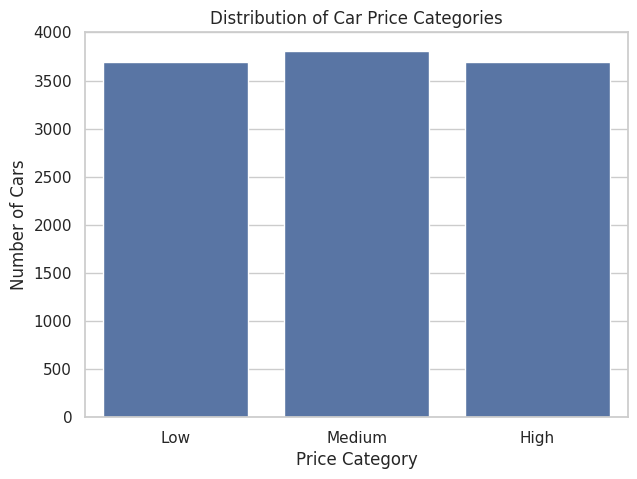

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Price_Category',
    order=['Low', 'Medium', 'High']
)

plt.title('Distribution of Car Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Number of Cars')
plt.show()

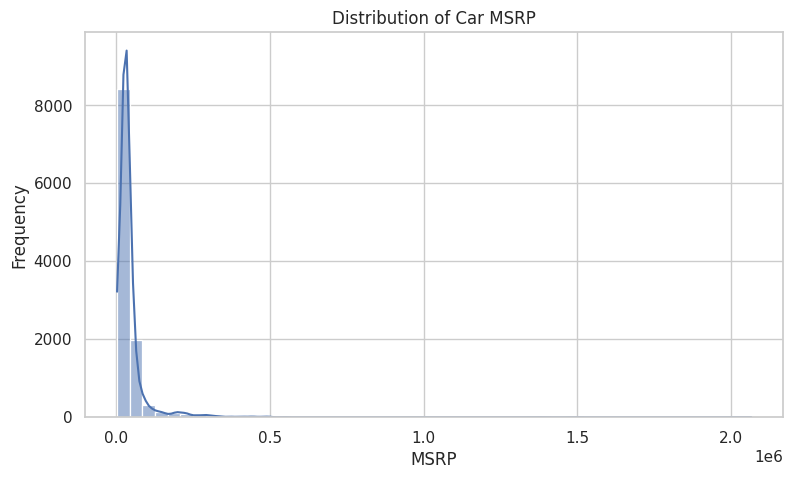

In [ ]:
#histogram
plt.figure(figsize=(9,5))

sns.histplot(df['MSRP'], bins=50, kde=True)

plt.title('Distribution of Car MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

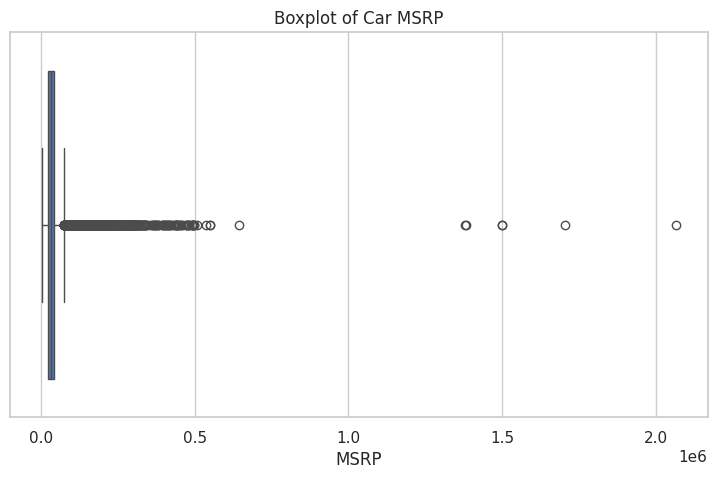

In [ ]:
#boxplot
plt.figure(figsize=(9,5))

sns.boxplot(x=df['MSRP'])

plt.title('Boxplot of Car MSRP')
plt.xlabel('MSRP')
plt.show()

In [ ]:
#outlier detection using IQR
Q1 = df['MSRP'].quantile(0.25)
Q3 = df['MSRP'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['MSRP'] < lower_bound) |
    (df['MSRP'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Number of outliers:", len(outliers))

Q1: 21599.5
Q3: 43032.5
IQR: 21433.0
Number of outliers: 960


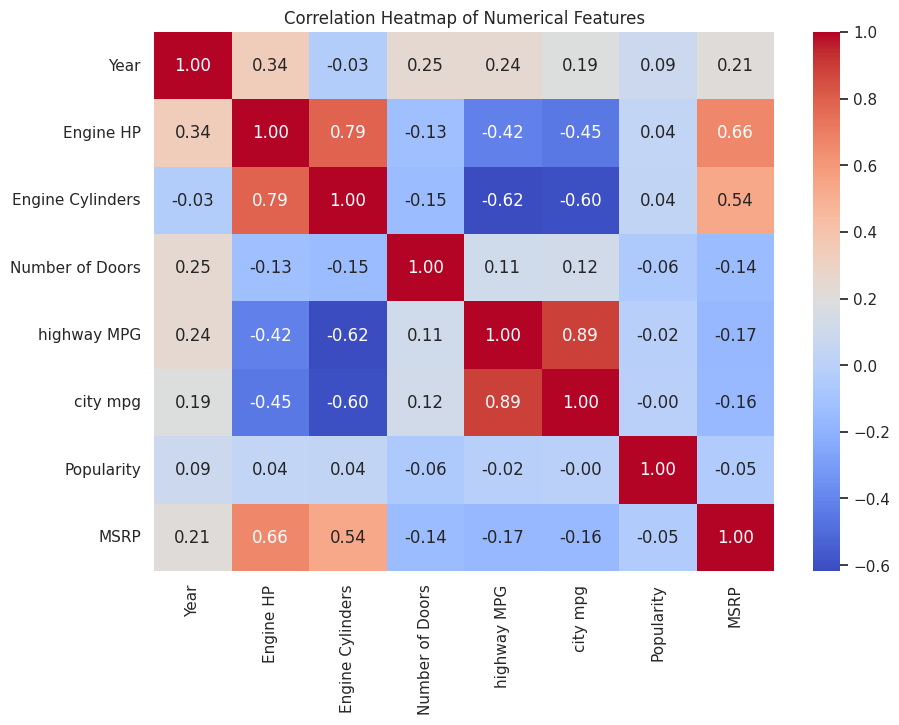

In [ ]:
#Correlation heatmap
numeric_cols = [
    'Year',
    'Engine HP',
    'Engine Cylinders',
    'Number of Doors',
    'highway MPG',
    'city mpg',
    'Popularity',
    'MSRP'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

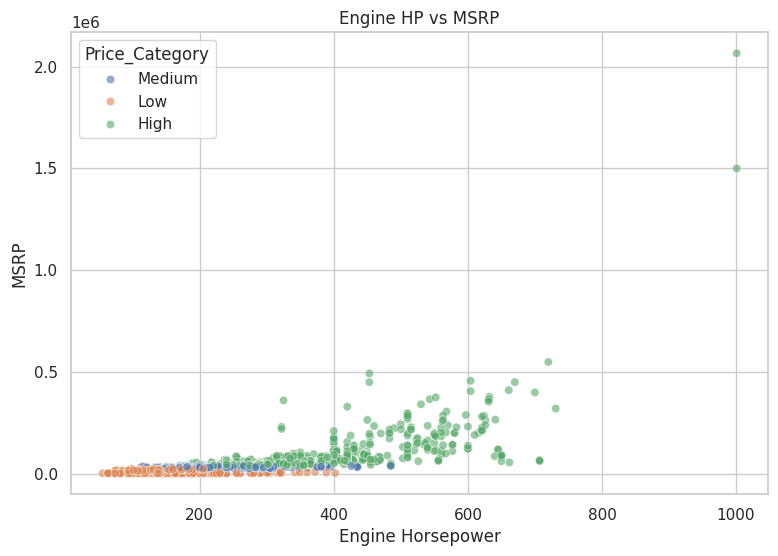

In [ ]:
#Engine HP vs MSRP
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df.sample(min(3000, len(df)), random_state=42),
    x='Engine HP',
    y='MSRP',
    hue='Price_Category',
    alpha=0.6
)

plt.title('Engine HP vs MSRP')
plt.xlabel('Engine Horsepower')
plt.ylabel('MSRP')
plt.show()

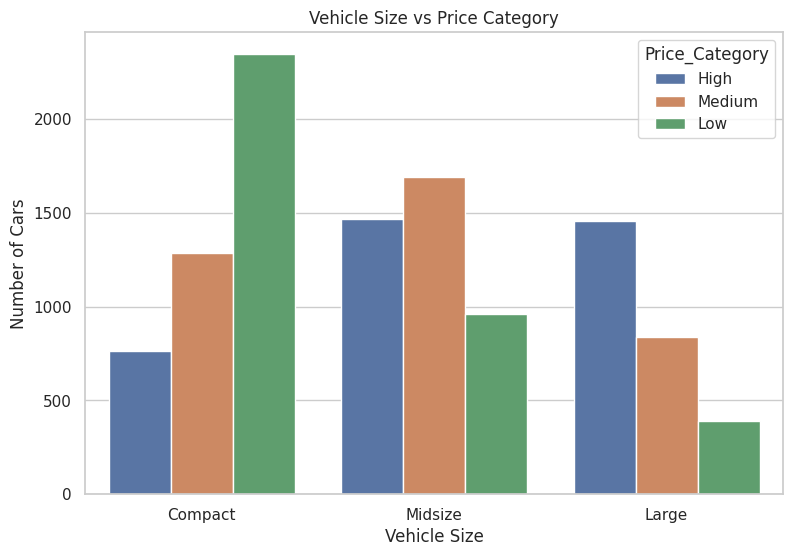

In [ ]:
#Vehicle size vs price category
plt.figure(figsize=(9,6))

sns.countplot(
    data=df,
    x='Vehicle Size',
    hue='Price_Category'
)

plt.title('Vehicle Size vs Price Category')
plt.xlabel('Vehicle Size')
plt.ylabel('Number of Cars')
plt.show()

In [ ]:
X = df.drop(
    columns=['MSRP', 'Price_Category', 'Model'],
    errors='ignore'
)

y = df['Price_Category']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['Make', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity']

Target:
Price_Category
Medium    3811
Low       3696
High      3692
Name: count, dtype: int64


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8959
Testing samples: 2240


In [ ]:
#Identify numerical and categorical columns
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']

Categorical features:
['Make', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']


In [ ]:
#Preprocessing pipeline
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
#Define models
models = {

    'Logistic Regression': LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='lbfgs'
    ),

    'Decision Tree': DecisionTreeClassifier(
        criterion='gini',
        max_depth=12,
        min_samples_split=10,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='minkowski'
    ),

    'SVM': SVC(
        C=1.0,
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
#Train all models
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} training completed.")


Training Logistic Regression...
Logistic Regression training completed.

Training Decision Tree...
Decision Tree training completed.

Training KNN...
KNN training completed.

Training SVM...
SVM training completed.

Training Random Forest...
Random Forest training completed.


In [ ]:
#Evaluation
results = []

class_order = ['Low', 'Medium', 'High']

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    y_test_binary = label_binarize(
        y_test,
        classes=class_order
    )

    roc_auc = roc_auc_score(
        y_test_binary,
        y_prob,
        multi_class='ovr',
        average='weighted'
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by='F1-Score',
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Random Forest,0.895982,0.896797,0.895982,0.896289,0.269401
3,SVM,0.892857,0.893831,0.892857,0.893191,0.271998
0,Logistic Regression,0.869196,0.870232,0.869196,0.869570,0.262245
2,KNN,0.870089,0.868991,0.870089,0.869250,0.281809
1,Decision Tree,0.861161,0.859856,0.861161,0.860159,0.309215


In [ ]:
#classification reports
for name, model in trained_models.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=class_order,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

         Low       0.91      0.88      0.89       739
      Medium       0.90      0.90      0.90       739
        High       0.80      0.83      0.82       762

    accuracy                           0.87      2240
   macro avg       0.87      0.87      0.87      2240
weighted avg       0.87      0.87      0.87      2240


Decision Tree
              precision    recall  f1-score   support

         Low       0.88      0.91      0.89       739
      Medium       0.88      0.91      0.90       739
        High       0.82      0.77      0.79       762

    accuracy                           0.86      2240
   macro avg       0.86      0.86      0.86      2240
weighted avg       0.86      0.86      0.86      2240


KNN
              precision    recall  f1-score   support

         Low       0.89      0.91      0.90       739
      Medium       0.90      0.92      0.91       739
        High       0.83      0.78 

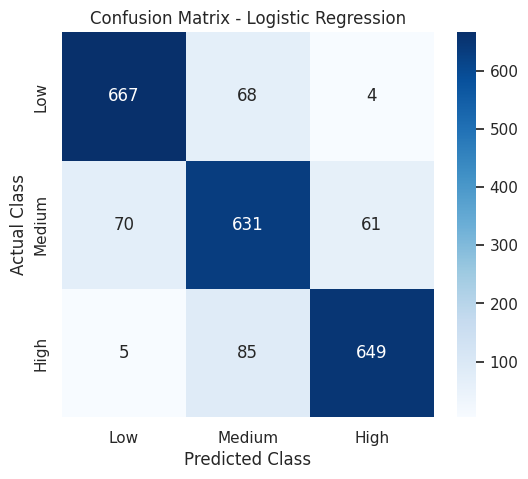

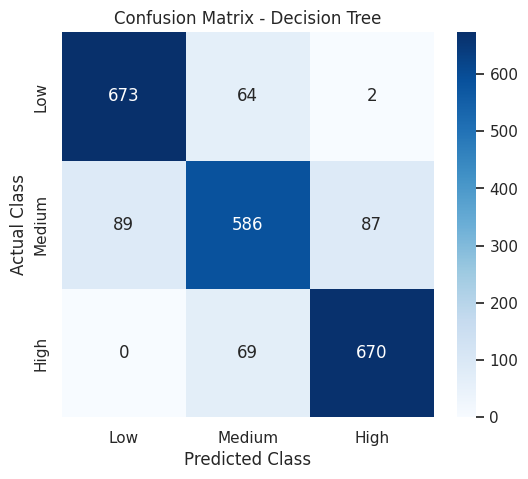

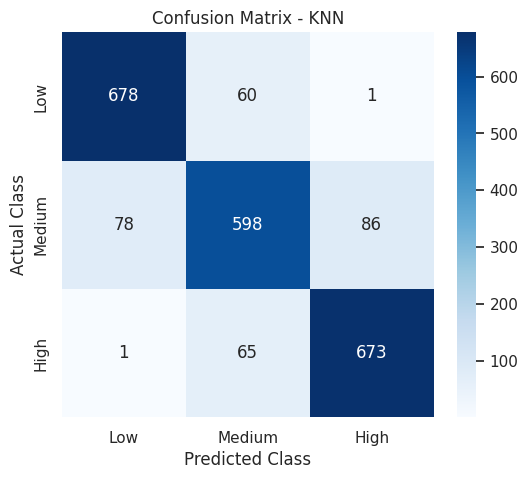

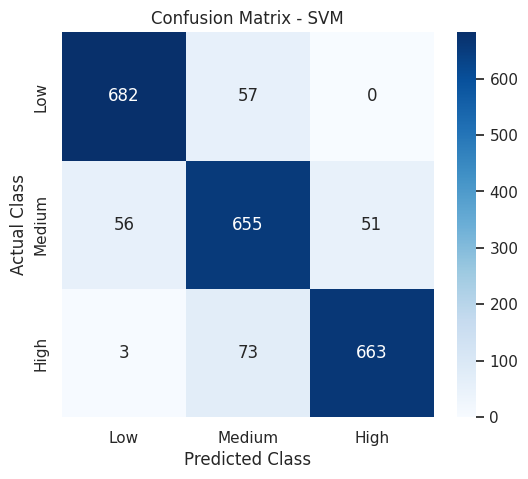

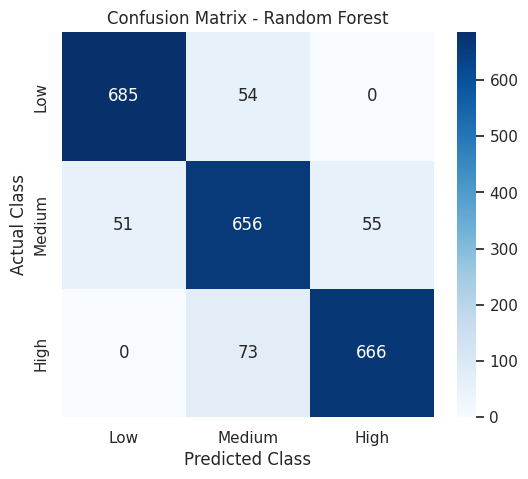

In [ ]:
#Confusion matrices
for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_order
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_order,
        yticklabels=class_order
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.show()

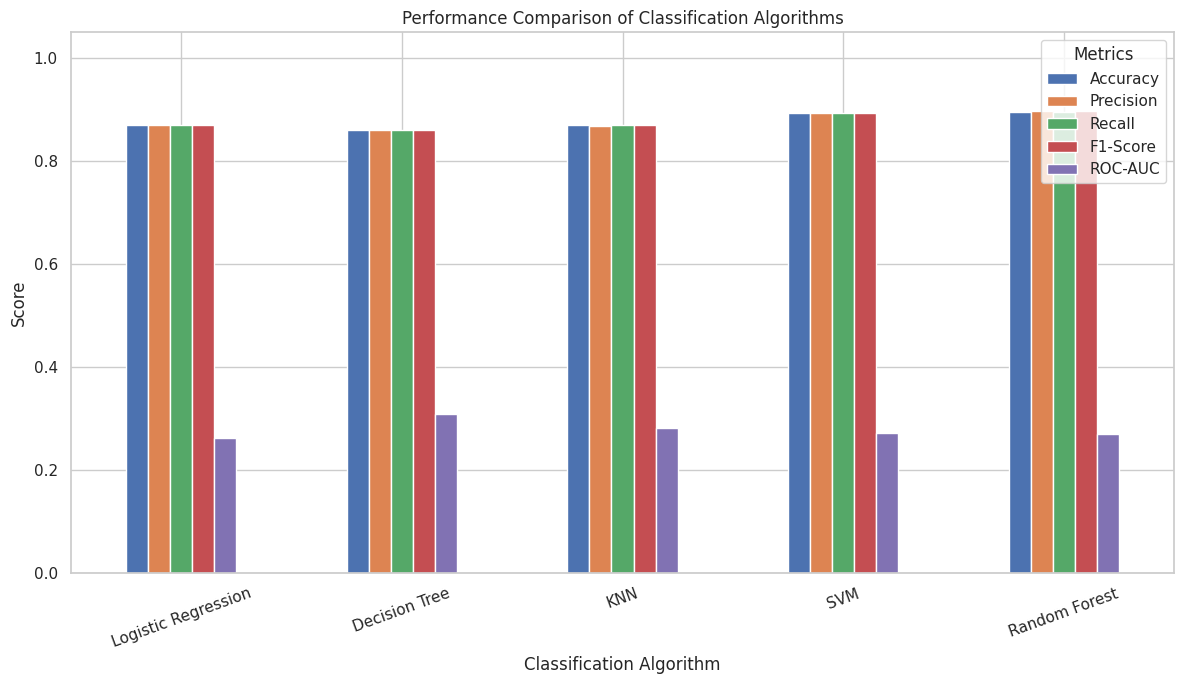

In [ ]:
#Comparison bar chart
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

results_plot = results_df.set_index('Model')[metrics]

results_plot.plot(
    kind='bar',
    figsize=(12,7)
)

plt.title('Performance Comparison of Classification Algorithms')
plt.xlabel('Classification Algorithm')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

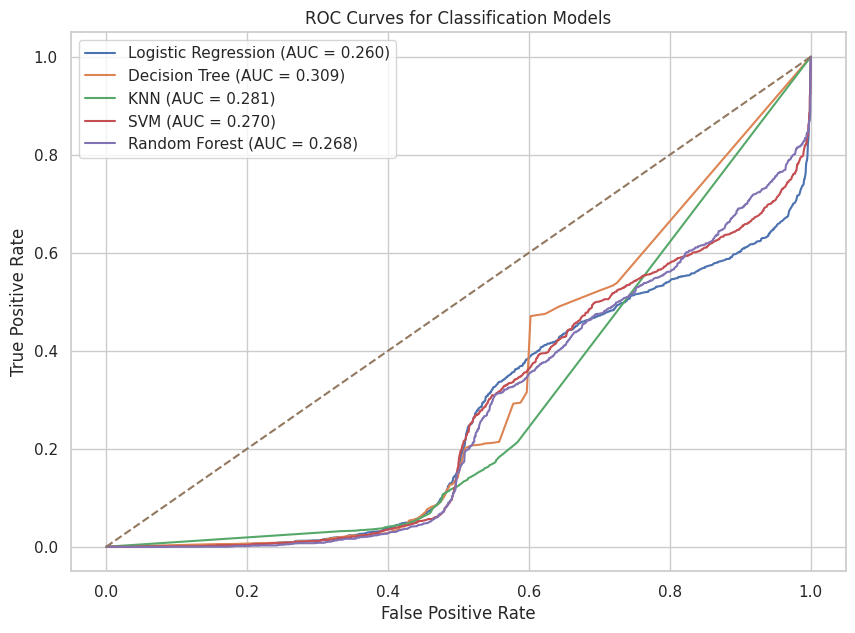

In [ ]:
#ROC curves
y_test_binary = label_binarize(
    y_test,
    classes=class_order
)

plt.figure(figsize=(10,7))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)

    fpr = dict()
    tpr = dict()

    for i in range(3):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            y_prob[:, i]
        )

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(3)]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(3):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= 3

    roc_auc_value = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f'{name} (AUC = {roc_auc_value:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend()
plt.show()

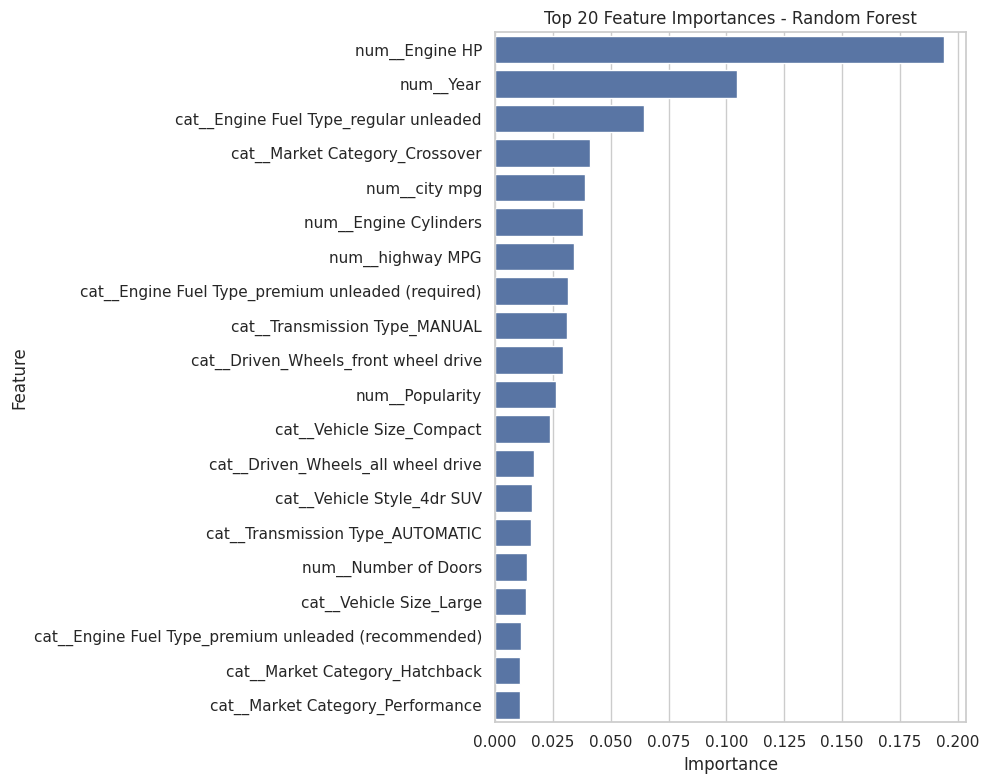

In [ ]:
#feature importance
rf_pipeline = trained_models['Random Forest']

preprocessor_fitted = rf_pipeline.named_steps['preprocessor']
rf_model = rf_pipeline.named_steps['classifier']

feature_names = preprocessor_fitted.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
#Save comparison table
results_df.to_csv(
    'classification_model_comparison.csv',
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


In [ ]:
#Save trained models
import joblib

for name, model in trained_models.items():

    filename = (
        name.lower()
        .replace(' ', '_')
        .replace('-', '')
        + '.pkl'
    )

    joblib.dump(
        model,
        filename
    )

    print("Saved:", filename)

Saved: logistic_regression.pkl
Saved: decision_tree.pkl
Saved: knn.pkl
Saved: svm.pkl
Saved: random_forest.pkl
